In [26]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import sklearn as sk
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score
import matplotlib.pyplot as plt
import sys
!{sys.executable} -m pip install matplotlib


[notice] A new release of pip is available: 24.3.1 -> 25.0
[notice] To update, run: python.exe -m pip install --upgrade pip


## Classification

In [1]:
def classify(true_labels, true_numeric, pred): 
    class_labels = np.unique(true_numeric)
    print(accuracy_score(true_numeric, pred))
    print(classification_report(true_numeric, pred))
    cm = confusion_matrix(y_pred=pred, y_true=true_numeric, labels=class_labels)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

In [4]:
df = pd.read_csv('data/real_dataset_normalized_by_cptac.tsv', sep="\t", index_col=0).T.reset_index(drop=True)
df.columns = df.columns.astype(str)
data = df.iloc()[:,:-1]
label = df.iloc()[:,-1]

C:\Users\piako\AppData\Local\Temp\ipykernel_3984\2857537052.py:1: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/real_dataset_normalized_by_cptac.tsv', sep="\t", index_col=0).T.reset_index(drop=True)


In [5]:
# Reduce dimensionality using PCA to 2 components for visualization
def kmeans(data, label, k=2, pca_components=2):
    pca = PCA(n_components=pca_components)
    data_pca = pca.fit_transform(data)

    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(data_pca)

    # Scatter plot of clusters
    plt.figure(figsize=(8, 5))
    plt.scatter(data_pca[:, 0], data_pca[:, 1], c=clusters, cmap='viridis', alpha=0.7)
    plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, c='red', marker='X', label='Centroids')
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')
    plt.title('K-Means Clustering with cluster labels')
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.scatter(data_pca[:, 0], data_pca[:, 1],  c=label, cmap='plasma', alpha=0.7)
    plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, c='red', marker='X', label='Centroids')
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')
    plt.title('K-Means Clustering with real labels')
    plt.legend()
    plt.show()
    return clusters

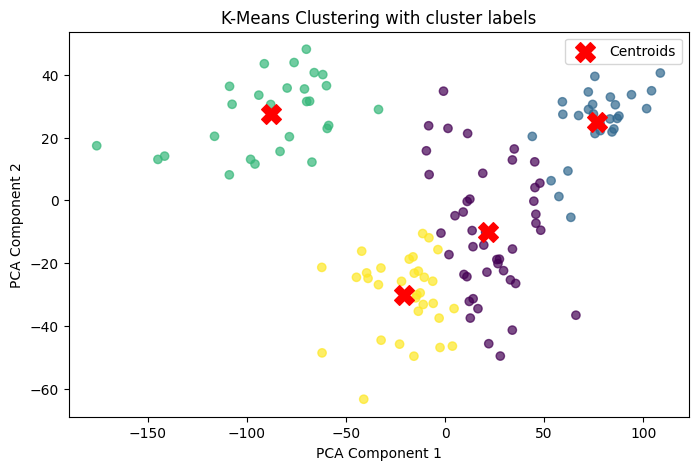

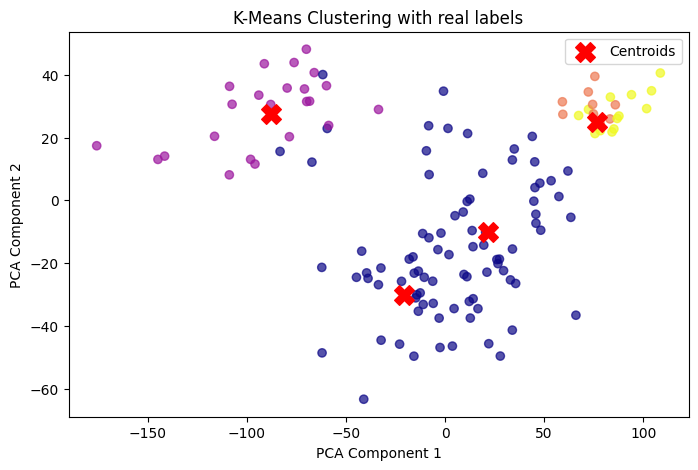

0.3384615384615385
              precision    recall  f1-score   support

           0       1.00      0.52      0.68        85
           1       0.00      0.00      0.00        23
           2       0.00      0.00      0.00         9
           3       0.00      0.00      0.00        13

    accuracy                           0.34       130
   macro avg       0.25      0.13      0.17       130
weighted avg       0.65      0.34      0.45       130



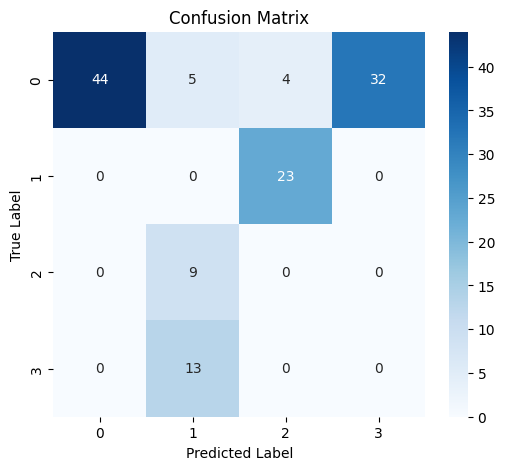

In [15]:
data = df.iloc()[:,:-1]
label = df.iloc()[:,-1]
label_mapping = {' Primary Tumor': 0, ' Solid Tissue Normal': 1, 'Ovarian Tumor Sample': 2, ' Not Reported': 3}
class_labels = [0,1,2,3]
y_true_numeric = np.array([label_mapping[l] for l in label])
cluster_label = kmeans(data, y_true_numeric, 4, 2)
classify(label, y_true_numeric, cluster_label)

## Only for 2 classes Tumor or not

In [9]:
all_true_label = pd.DataFrame(label).reset_index(drop=True)
df_compare_kmeans = pd.concat([data.reset_index(drop=True), label], axis=1)
df_compare_kmeans = df_compare_kmeans[~df_compare_kmeans.apply(lambda row: row.astype(str).isin([" Not Reported", "Ovarian Tumor Sample"])).any(axis=1)]

In [10]:
data4kmeans = df_compare_kmeans.iloc[:,:-1]
label4kmeans =df_compare_kmeans.iloc[:,-1]
label_mapping = {' Primary Tumor': 0, ' Solid Tissue Normal': 1}
label_numeric = np.array([label_mapping[label] for label in label4kmeans])

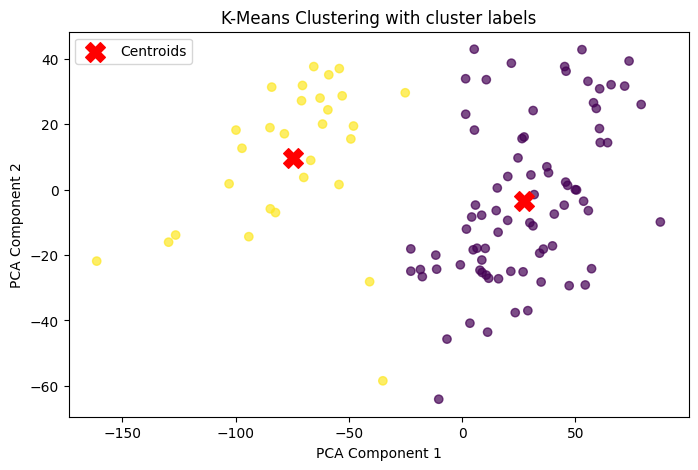

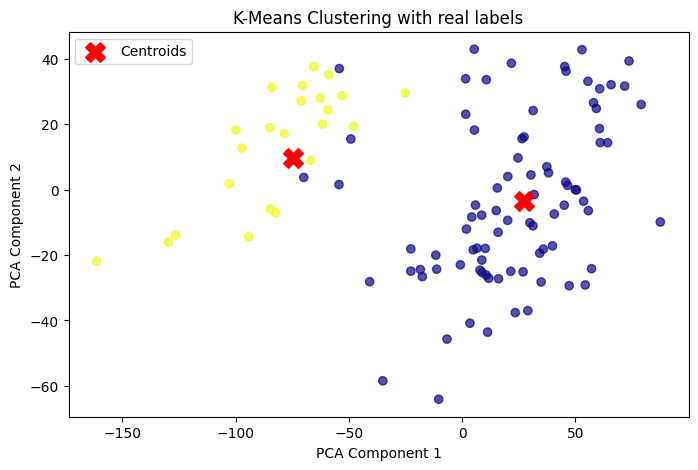

Accuracy: 0.9444444444444444
Recall: 1.0
F1 Score: 0.8846153846153846
Precision: 0.7931034482758621
0.9444444444444444
              precision    recall  f1-score   support

           0       1.00      0.93      0.96        85
           1       0.79      1.00      0.88        23

    accuracy                           0.94       108
   macro avg       0.90      0.96      0.92       108
weighted avg       0.96      0.94      0.95       108



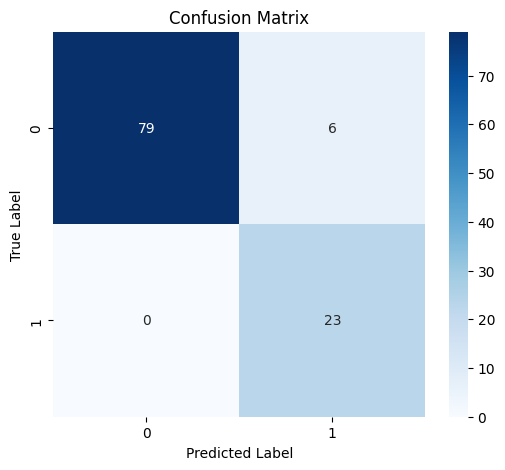

In [28]:
cluster_label = kmeans(data4kmeans, label_numeric, 2, 2)
accuracy = accuracy_score(label_numeric, cluster_label)
recall = recall_score(label_numeric, cluster_label)
f1 = f1_score(label_numeric, cluster_label)
precision = precision_score(label_numeric, cluster_label)

print(f"Accuracy: {accuracy}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
print(f"Precision: {precision}")

classify(label4kmeans, label_numeric, cluster_label)